<a href="https://colab.research.google.com/github/natalstein/codecademy_assignments/blob/main/SpEchem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [164]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt


In this notebook I create a global fitting for UV- vid spectroelectrochemical experiments

Here is the basic Nerst equation function Nerst(C_t, n, E_o, E_app). This function requires total concentration of species to be reduced - C_t. E_o and E_app are the standard redox potential and the applied pottentional, respectively in V. n is the number of electrons trasfered in the reachtion. The function returns the concentration of reduced species.

In [165]:

C_t = 0.05
n = 1
E_o = 0.25
E_app = np.arange(-1.25, 2.75, 0.1)
def Nerst(C_t,n, E_o, E_app):
  U = np.exp(-((E_app-E_o)*n)/0.59)
  C_r = (C_t*U)/(1+U)
  return C_r

The following is the absorbtion_peak(lam, mu, sigma,E_net,C). lam is a range of wavelength, mu is the maximum peak, sigma is a Full Width at Half Maximum (FWHM) divided by 2.355. Because some species have absorbtion at the same wavelength E_net is used in the function. And concentration C in molar is used.

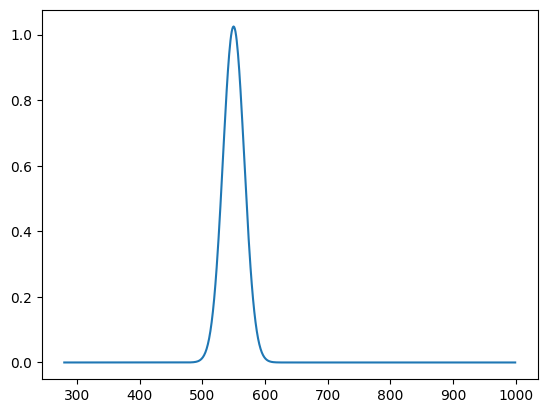

In [166]:
FWHM = 40
sigma = FWHM/2.355
mu = 550
E_red = 29.5
E_ox = 9.0
E_net = E_red - E_ox
lam = np.arange(280, 1000, 1)
T = 298.15
n =1
def absorbtion_peak(lam, mu, sigma,E_net,C):
  A = E_net*np.exp(-(lam - mu)**2/(2*sigma**2))*C
  return A

plt.plot(lam, absorbtion_peak(lam, mu, sigma, E_net,C_t))


Finally, the Nerst and absorbtion_peak functions are used to simmulate the data.


In [167]:
reduced_conc = Nerst(C_t,n, E_o, E_app)

wavelengths = np.arange(280, 1000, 1)

Abs = np.zeros((len(E_app), len(wavelengths)))
for i in range( len(E_app)):
  Abs[i,:] = absorbtion_peak(wavelengths, mu, sigma, E_net, reduced_conc[i])

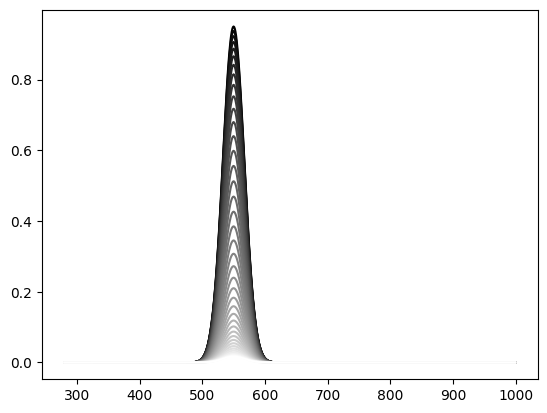

In [168]:
for i in range(len(E_app)):
  plt.plot(wavelengths, Abs[i,:], color = plt.cm.gray(i / (len(E_app) - 1)))

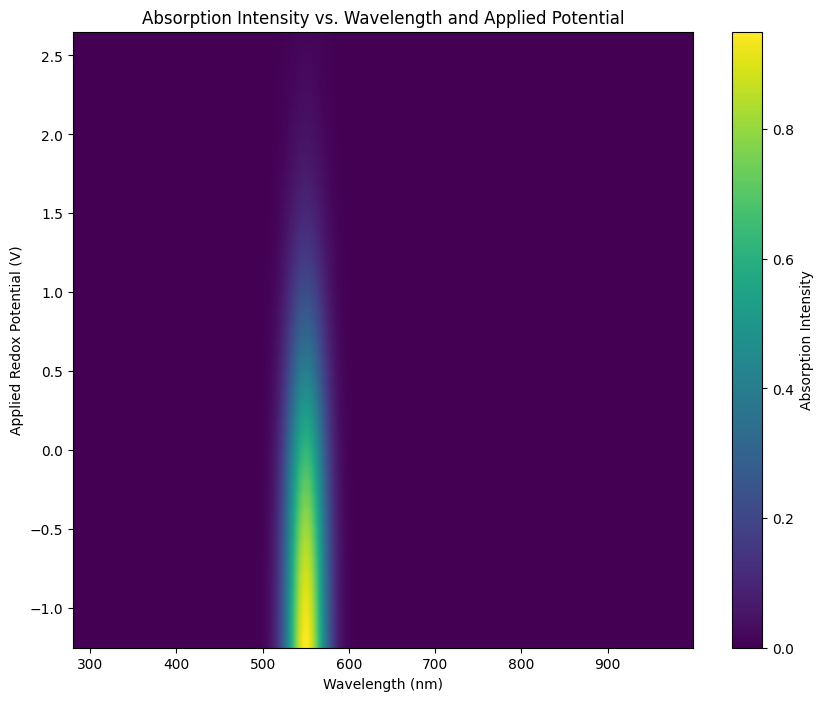

In [169]:
plt.figure(figsize=(10, 8))
plt.imshow(Abs, aspect='auto',
           extent=[wavelengths.min(), wavelengths.max(), E_app.min(), E_app.max()],
           origin='lower', cmap='viridis')
plt.colorbar(label='Absorption Intensity')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Applied Redox Potential (V)')
plt.title('Absorption Intensity vs. Wavelength and Applied Potential')
plt.show()